# Klassificering av ansiktsuttryck med Deep Learning

## Introduktion

I denna uppgift bygger jag en CNN-modell (Convolutional Neural Network) för att klassificera ansiktsuttryck med hjälp av FER-2013-datasetet.

Målet är att undersöka hur väl en djupinlärningsmodell kan lära sig att känna igen olika känslor från bilder av ansikten.

Arbetet följer uppgiftens struktur:

1. Förstå datan
2. Förbereda datan
3. Bygga modellen
4. Träna modellen
5. Utvärdera modellen
6. Göra prediktioner på ny data
7. Analysera resultatet
8. Reflektera över arbetet

In [84]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

## 1. Förstå datan

I detta steg undersöker jag datasetet innan modellen byggs.

Jag kontrollerar:
- vilka klasser som finns i träningsdatan
- hur många bilder som finns i varje klass
- om datan verkar balanserad eller obalanserad

In [85]:
train_dir = "../data/FER-2013/train"
test_dir = "../data/FER-2013/test"

print("Train-mapp:", train_dir)
print("Test-mapp:", test_dir)

Train-mapp: ../data/FER-2013/train
Test-mapp: ../data/FER-2013/test


In [86]:
classes = os.listdir(train_dir)

print("Klasser i datasetet:")
print(classes)
print()
print("Antal klasser:", len(classes))

Klasser i datasetet:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Antal klasser: 7


In [87]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    num_images = len(os.listdir(class_path))
    class_counts[class_name] = num_images

print("Antal bilder per klass:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Antal bilder per klass:

angry: 3995
disgust: 436
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171


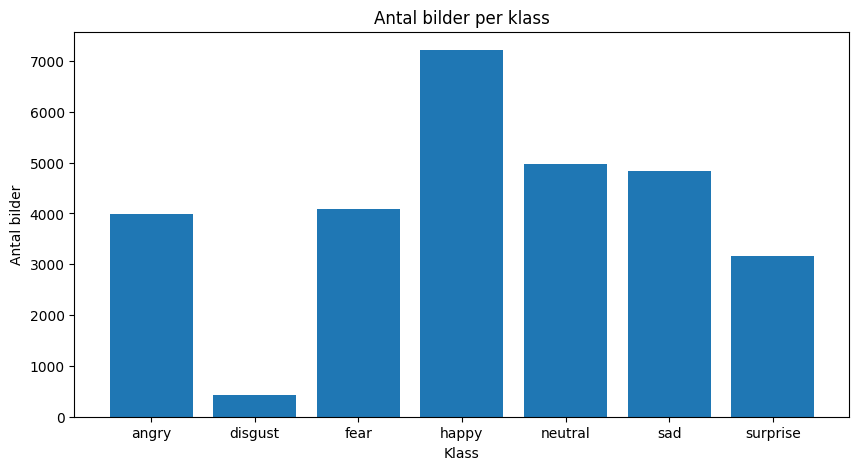

In [88]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())

plt.title("Antal bilder per klass")
plt.xlabel("Klass")
plt.ylabel("Antal bilder")

plt.show()

### Analys av datan

Datasetet innehåller sju olika klasser:

- angry
- disgust
- fear
- happy
- neutral
- sad
- surprise

Antalet bilder skiljer sig mellan klasserna. Klassen happy innehåller flest bilder (7215), medan disgust innehåller betydligt färre bilder (436).

Detta innebär att datasetet är obalanserat. Modellen kommer att få fler exempel att lära sig från vissa klasser än andra, vilket kan påverka resultatet.

Trots detta innehåller de flesta klasser flera tusen bilder, vilket ger goda förutsättningar för att träna en CNN-modell.

## 2. Förbered datan

I detta steg förbereder jag bilderna för träning av modellen.

Jag kommer att:
- läsa in bilderna
- normalisera pixelvärdena
- skapa tränings- och valideringsdata
- kontrollera att bilderna läses in korrekt

In [89]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [90]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


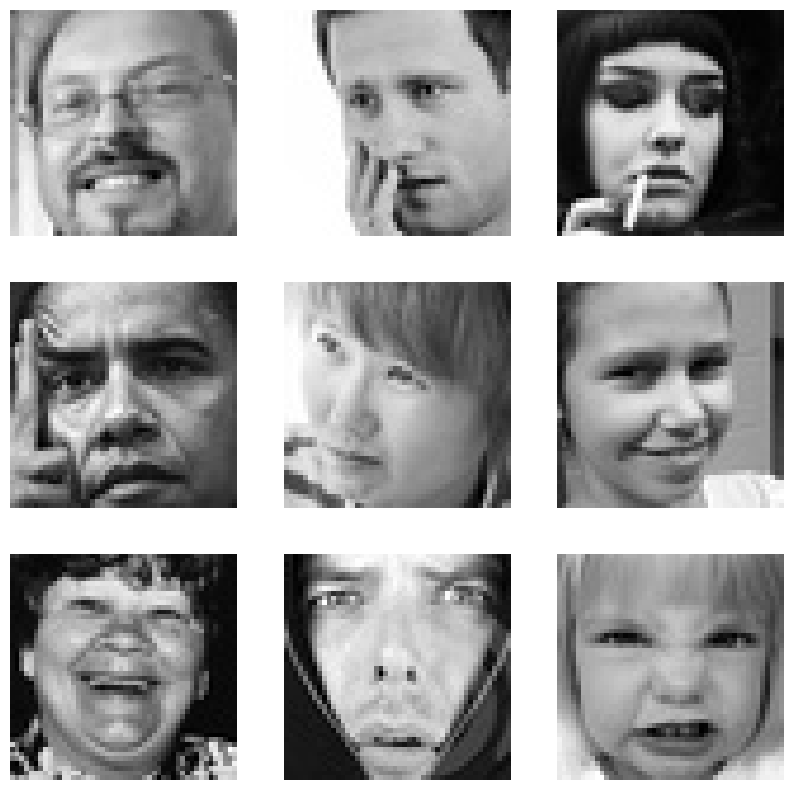

In [91]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].reshape(48, 48), cmap="gray")
    plt.axis("off")

plt.show()

### Kontroll av inläsning

För att säkerställa att bilderna lästes in korrekt visades ett antal exempelbilder från träningsdatan.

Bilderna visas i gråskala med storleken 48x48 pixlar. Bilderna har även normaliserats så att pixelvärdena ligger mellan 0 och 1.

Kontrollen visar att bilderna kan läsas in korrekt och att datan är redo att användas för träning av modellen.

## 3. Bygga modellen

I detta steg bygger jag en CNN-modell (Convolutional Neural Network) som ska lära sig att klassificera ansiktsuttryck.

Modellen består av:
- konvolutionslager (Conv2D) för att hitta mönster i bilderna
- poolinglager (MaxPooling2D) för att minska mängden data
- dense-lager för klassificering
- ett output-lager med sju neuroner, en för varje klass

In [92]:
model = models.Sequential([
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(48, 48, 1)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(
        7,
        activation="softmax"
    )
])

In [93]:
print(images.shape)

(32, 48, 48, 1)


In [94]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,935 (1.64 MB)

 Trainable params: 428,935 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

### Modellens struktur

Modellen består av två konvolutionslager (Conv2D) som används för att hitta mönster i bilderna, exempelvis kanter, former och ansiktsdrag.

Efter varje konvolutionslager används ett MaxPooling2D-lager för att minska mängden data och göra modellen mer effektiv.

Flatten-lagret omvandlar bildinformationen till en endimensionell vektor som kan användas av de fullständigt kopplade lagren.

Det första Dense-lagret innehåller 64 neuroner och används för att lära sig mer komplexa samband i datan.

Det sista Dense-lagret innehåller 7 neuroner eftersom datasetet innehåller sju olika känsloklasser. Softmax används för att beräkna sannolikheten för varje klass.

## 4. Träna modellen

I detta steg kompileras och tränas modellen.

Jag använder:
- Adam som optimerare
- categorical_crossentropy som förlustfunktion
- accuracy som utvärderingsmått

Under träningen följer jag hur modellens träffsäkerhet utvecklas på tränings- och valideringsdatan.

In [95]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [96]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3622 - loss: 1.6269 - val_accuracy: 0.3853 - val_loss: 1.5763
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4672 - loss: 1.3931 - val_accuracy: 0.4684 - val_loss: 1.3695
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5146 - loss: 1.2802 - val_accuracy: 0.4881 - val_loss: 1.3535
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5537 - loss: 1.1871 - val_accuracy: 0.5034 - val_loss: 1.3085
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5892 - loss: 1.1049 - val_accuracy: 0.5081 - val_loss: 1.3308
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.6274 - loss: 1.0150 - val_accuracy: 0.5182 - val_loss: 1.3454
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6597 - loss: 0.9271 - val_accuracy: 0.5201 - val_loss: 1.3425
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6969 - loss: 0.8299 - 

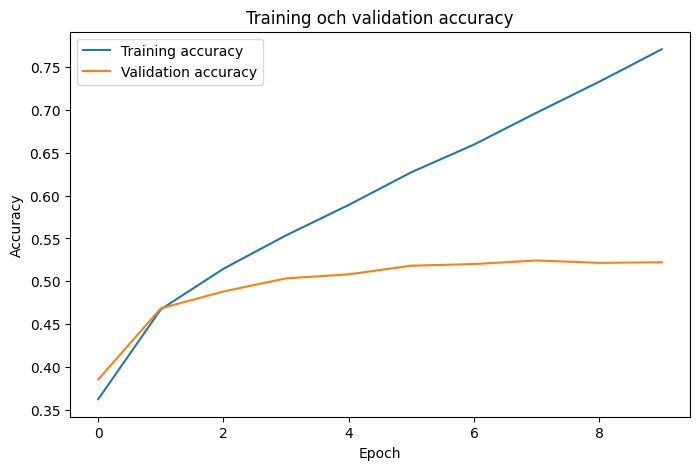

In [97]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Training och validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

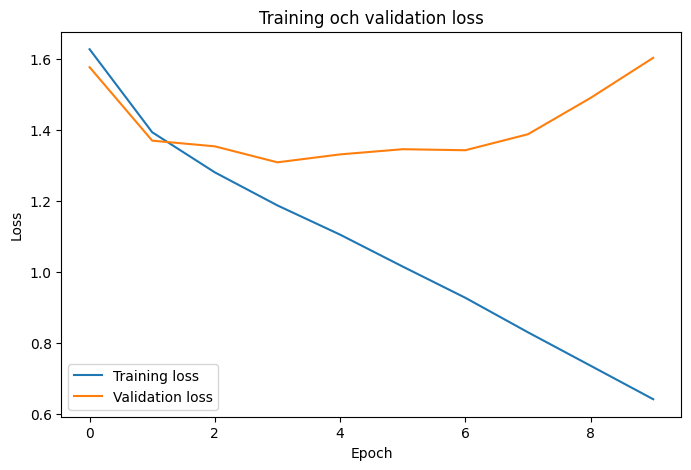

In [98]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Training och validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Resultat från träningen

Modellen tränades under 10 epochs.

Träningsaccuracy ökade från cirka 36 % till 77 %, vilket visar att modellen lärde sig mönster i träningsdatan.

Valideringsaccuracy ökade till cirka 52 %, men förbättrades inte i samma takt som träningsaccuracy.

Träningskurvorna visar att träningsaccuracy ökade kontinuerligt under hela träningen, medan valideringsaccuracy planade ut efter några epochs.

Samtidigt minskade träningsförlusten (training loss), medan valideringsförlusten (validation loss) började öka mot slutet av träningen.

Detta tyder på att modellen började överanpassa sig till träningsdatan (overfitting), vilket innebär att den lärde sig träningsdatan bättre än den kunde generalisera till ny data.

Resultatet visar att modellen fungerar och kan identifiera ansiktsuttryck med en rimlig träffsäkerhet. Samtidigt finns det utrymme för förbättringar för att öka prestandan på ny data och minska överanpassningen till träningsdatan.

## 5. Utvärdera modellen

I detta steg utvärderas modellen på testdatan.

Målet är att undersöka hur bra modellen presterar på bilder som den inte har sett tidigare under träningen.

In [99]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5174 - loss: 1.5891
Test Loss: 1.589142918586731
Test Accuracy: 0.5174143314361572


### Resultat från utvärderingen

Modellen utvärderades på testdatan, som inte användes under träningen.

Testaccuracy blev cirka 51,7 %, vilket innebär att modellen klassificerade ungefär hälften av testbilderna korrekt.

Resultatet ligger nära valideringsaccuracy från träningen, vilket visar att modellen presterar ungefär lika bra på ny data som på valideringsdatan.

Trots att modellen lärde sig träningsdatan väl visar resultatet att det fortfarande finns utrymme för förbättringar. En möjlig förklaring är att datasetet är obalanserat och att modellen började överanpassa sig till träningsdatan.

# Förbättra modellen med Dropout

För att undersöka om modellen kan förbättras testar jag en ny modell med Dropout.

Dropout är en regulariseringsteknik som slumpmässigt stänger av vissa neuroner under träningen. Detta kan minska overfitting och hjälpa modellen att generalisera bättre till nya bilder.

In [100]:
model_dropout = models.Sequential([
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(48, 48, 1)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        7,
        activation="softmax"
    )
])

In [101]:
model_dropout.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_dropout = model_dropout.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2757 - loss: 1.7661 - val_accuracy: 0.3623 - val_loss: 1.6148
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3480 - loss: 1.6229 - val_accuracy: 0.4053 - val_loss: 1.5272
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3794 - loss: 1.5602 - val_accuracy: 0.4410 - val_loss: 1.4737
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4013 - loss: 1.5144 - val_accuracy: 0.4564 - val_loss: 1.4365
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4206 - loss: 1.4709 - val_accuracy: 0.4649 - val_loss: 1.3973
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4305 - loss: 1.4473 - val_accuracy: 0.4703 - val_loss: 1.3760
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4407 - loss: 1.4222 - val_accuracy: 0.4792 - val_loss: 1.3660
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4473 - loss: 1.4003 - 

In [102]:
dropout_loss, dropout_accuracy = model_dropout.evaluate(test_generator)

print("Dropout Test Loss:", dropout_loss)
print("Dropout Test Accuracy:", dropout_accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4836 - loss: 1.3302
Dropout Test Loss: 1.330197811126709
Dropout Test Accuracy: 0.4835608899593353


## Träningskurvor för Dropout-modellen

För att analysera hur Dropout påverkade modellen visualiseras accuracy och loss under träningen.

Kurvorna används för att undersöka om modellen visar tecken på overfitting och för att jämföra resultaten med baseline-modellen.

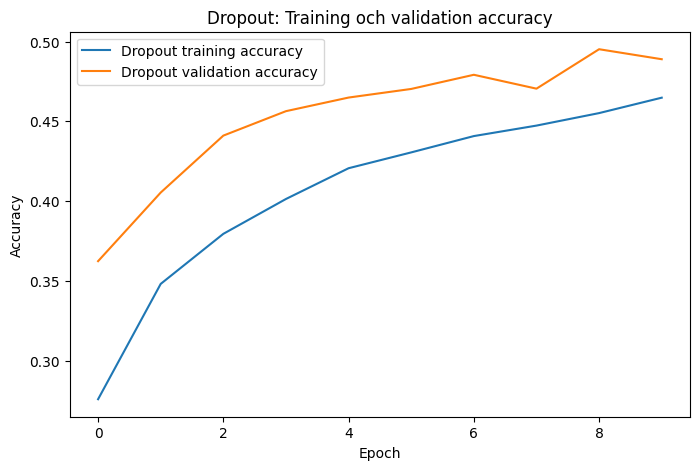

In [103]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_dropout.history["accuracy"],
    label="Dropout training accuracy"
)

plt.plot(
    history_dropout.history["val_accuracy"],
    label="Dropout validation accuracy"
)

plt.title("Dropout: Training och validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

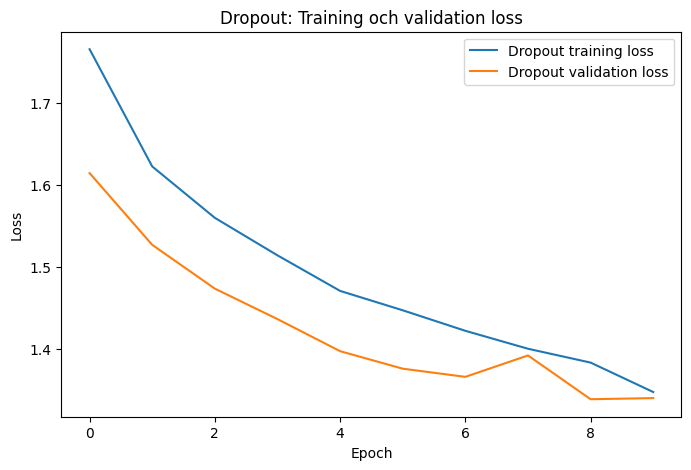

In [104]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_dropout.history["loss"],
    label="Dropout training loss"
)

plt.plot(
    history_dropout.history["val_loss"],
    label="Dropout validation loss"
)

plt.title("Dropout: Training och validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Analys av Dropout-kurvorna

Accuracy-kurvorna visar att Dropout-modellen lärde sig långsammare än baseline-modellen.

Validation accuracy nådde ungefär 49 %, vilket var något lägre än baseline-modellens cirka 52 %.

Loss-kurvorna visar att modellen fortfarande hade svårt att generalisera perfekt till ny data, men experimentet visar hur regularisering påverkar modellens inlärning.

I detta fall förbättrade inte Dropout resultatet, men det gav en djupare förståelse för hur olika modellval påverkar prestandan.

## Jämförelse mellan modeller

Jag jämförde min baseline-modell med en modell som använder Dropout.

Baseline-modellen uppnådde cirka 51,7 % accuracy på testdatan.

Dropout-modellen uppnådde cirka 48,4 % accuracy på testdatan.

Dropout testades för att minska overfitting genom att slumpmässigt stänga av neuroner under träningen.

I detta fall gav Dropout-modellen något lägre accuracy än baseline-modellen. Det kan bero på att modellen redan var relativt enkel eller att Dropout-värdet 0,5 gjorde att för mycket information togs bort under träningen.

Trots att resultatet inte förbättrades visar experimentet hur regularisering påverkar modellens inlärning och förmåga att generalisera.

Experimentet visar också att förändringar i en modell inte alltid leder till bättre resultat, vilket är en viktig del av arbetet med deep learning.

### Spara modellen

Efter träning och utvärdering sparades modellen i Keras-format (.keras) så att den kan användas senare utan att behöva tränas om modellen från början.

In [105]:
model.save("../models/ansiktsmodell.keras")

print("Modellen har sparats.")

Modellen har sparats.


## 6. Göra prediktioner på ny data

I detta steg används modellen för att göra prediktioner på bilder från testdatan.

Målet är att undersöka vilka känslor modellen förutspår och jämföra dessa med de faktiska klasserna.

In [106]:
predictions = model.predict(test_generator)

print(predictions.shape)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
(7178, 7)


In [107]:
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:10])

[0 4 5 4 0 2 0 2 5 0]


In [108]:
class_names = list(test_generator.class_indices.keys())

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [109]:
true_classes = test_generator.classes

print(true_classes[:10])

[0 0 0 0 0 0 0 0 0 0]


In [110]:
for i in range(10):
    print(
        f"Bild {i+1}: "
        f"Faktisk = {class_names[true_classes[i]]}, "
        f"Prediktion = {class_names[predicted_classes[i]]}"
    )

Bild 1: Faktisk = angry, Prediktion = angry
Bild 2: Faktisk = angry, Prediktion = neutral
Bild 3: Faktisk = angry, Prediktion = sad
Bild 4: Faktisk = angry, Prediktion = neutral
Bild 5: Faktisk = angry, Prediktion = angry
Bild 6: Faktisk = angry, Prediktion = fear
Bild 7: Faktisk = angry, Prediktion = angry
Bild 8: Faktisk = angry, Prediktion = fear
Bild 9: Faktisk = angry, Prediktion = sad
Bild 10: Faktisk = angry, Prediktion = angry


### Exempel på prediktioner

För att undersöka modellens prediktioner jämfördes modellens förutsagda klass med den faktiska klassen för några bilder från testdatan.

Resultatet visar att modellen ibland klassificerar bilderna korrekt, men att den också förväxlar vissa känslor med varandra.

Exempelvis förutsågs några bilder med klassen angry som fear, sad eller surprise.

Detta visar att uppgiften är relativt svår eftersom vissa ansiktsuttryck kan likna varandra.

In [111]:
from tensorflow.keras.utils import load_img, img_to_array

image_path = "../testbild/PrivateTest_647018.jpg"

img = load_img(
    image_path,
    target_size=(48, 48),
    color_mode="grayscale"
)

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

print("Modellen tror att bilden visar:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Modellen tror att bilden visar: happy


### Prediktion på en enskild bild

För att testa modellen på en enskild bild laddades en bild in från testmappen och förbehandlades på samma sätt som träningsdatan.

Modellen förutsåg att bilden tillhör klassen **happy**.

Detta visar att modellen kan användas för att göra prediktioner på nya bilder utanför träningsprocessen.

## 7. Analysera resultatet

I detta steg analyseras modellens resultat.

Målet är att undersöka modellens styrkor och svagheter samt diskutera möjliga orsaker till resultaten.

### Analys

Modellen uppnådde cirka 77 % accuracy på träningsdatan men endast cirka 51,7 % på testdatan.

Skillnaden mellan träningsaccuracy och testaccuracy tyder på att modellen har överanpassat sig (overfitting) till träningsdatan.

En möjlig orsak är att datasetet är obalanserat. Klassen happy innehåller betydligt fler bilder än exempelvis disgust, vilket kan göra det svårare för modellen att lära sig vissa klasser.

Resultaten visar också att vissa känslor förväxlas med varandra. Detta är rimligt eftersom flera ansiktsuttryck har liknande visuella egenskaper.

Trots begränsningarna lyckades modellen klassificera ungefär hälften av testbilderna korrekt, vilket visar att den har lärt sig relevanta mönster i datan.

## 8. Reflektera över arbetet

I detta steg reflekterar jag över arbetet och vad jag har lärt mig under projektet.

### Reflektion

Under projektet har jag lärt mig hur man bygger och tränar en CNN-modell för bildklassificering med TensorFlow och Keras.

Jag har arbetat med att undersöka data, förbereda bilder, bygga en modell, träna den och utvärdera resultaten.

Resultaten visade att modellen kunde lära sig mönster i datan, men också att den hade svårt att generalisera till ny data. Detta gav en bättre förståelse för begrepp som overfitting och vikten av balanserad träningsdata.

Om jag skulle fortsätta utveckla modellen skulle jag testa fler lager, dropout och andra tekniker för att minska overfitting och förbättra modellens prestanda.

Projektet har gett en praktisk förståelse för hur djupinlärning används för bildklassificering i verkliga tillämpningar.

### Vad var svårast?

Det svåraste i uppgiften var att förstå hur bilddata skulle förberedas innan modellen kunde tränas samt att tolka modellens resultat och identifiera tecken på overfitting.

### Vad hade jag gjort annorlunda?

Om jag började om skulle jag tidigare testa flera modellvarianter och använda regularisering som Dropout redan från början. Jag skulle även experimentera med fler lager och fler epoker för att undersöka hur resultaten påverkas.

### Vilket betyg tycker jag att arbetet motsvarar?

Jag anser att arbetet motsvarar VG eftersom jag inte bara byggde och utvärderade en CNN-modell utan även jämförde flera modellvarianter.

Jag testade en förbättrad modell med Dropout och analyserade hur förändringen påverkade resultatet. Jag har också diskuterat modellens begränsningar, overfitting och möjliga förbättringar.

Genom att jämföra modeller och resonera kring resultaten har jag försökt visa en djupare förståelse för hur olika val påverkar en deep learning-modell.